# Parkinson's Disease Classifier
**ML Final Project 2025-2026** | ***University of Padova***

Group 4:
- Larissa Pereira Moraes
- Zainab Fatima
- Yousra Dehgane

***

## The Biological Problem

The question we are dealing with in this project is whether we can classify healthy individuals and Parkinson’s disease patients using voice biomarkers.

**Biological relevance:** Parkison's disease can cause vocal alterations in the early to mid stages of the disease, making it a possible factor to detect using a machine learning model as a low-cost diagnostic method (Xiu et al., 2024).

## Environment Setup

In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report, 
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay


from ucimlrepo import fetch_ucirepo as fetch_uci_dataset

# import sys
# !{sys.executable} -m pip install ucimlrepo

np.random.seed(42)

### Exploratory Data Analysis

Our dataset has:
- 195 voice recordings and,
- 22 feature variables

Each voice recording being a sample (row), and each feature a column describing a characteristic of the voice recording.

- **Metadata Columns:** name (dropped)
- **Input Features:** MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz), MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, Jitter:DDP, MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, Shimmer:DDA, NHR, HNR, RPDE, D2, DFA, spread1, spread2, PPE
- **Target:** status (1 = Parkinson's, 0 = healthy)


### Determining the Machine Learning Task

**Target type:**  
The target variable is categorical and binary. The `status` variable has two classes: `0` for healthy individuals and `1` for Parkinson’s disease patients.

**Problem type:**  
This is a supervised binary classification problem. The goal is to predict whether a subject is healthy or has Parkinson’s disease using voice measurement features.

**Compatible models:**  
Appropriate models include Logistic Regression, k-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest, and other classification models.

**Models that are not appropriate and why:**  
Regression models are not appropriate because the target is not a continuous numerical value. For example, Linear Regression or Random Forest Regressor would predict continuous values, while this task requires predicting one of two classes: healthy or Parkinson’s disease.



### Defining X and y
The feature matrix X has shape (195, 20), meaning that it contains 195 observations (voice recordings) and 20 features (after removing the duplicates). Each row corresponds to a voice recording from a subject, while each column represents a voice measurement used as a predictor in the machine learning model.

The target vector y has shape (195,), indicating that it contains one label for each observation in X. Each element represents the health status of the corresponding subject.

No transposition was required. The dataset was already organized in the standard machine learning format, with observations (voice recordings) as rows and features as columns. Therefore, X could be used directly for model training.


**What would happen if we changed the target?**
The same dataset can support different machine learning tasks depending on which variable is selected as the target. In this project, the target variable is status, making the problem a binary classification task (Parkinson's vs. healthy). However, if a continuous feature such as HNR or RPDE were selected as the target, the problem would become a regression task. Similarly, predicting a categorical variable with more than two classes would result in a multiclass classification problem. Therefore, the choice of target determines the learning objective and the appropriate evaluation metrics and algorithms.

In [6]:
# Dataset 5 - Parkinsons

parkinson = fetch_uci_dataset(id=174) # fetched data from UCI API

X_parkinson_raw = parkinson.data.features.copy()  
y_parkinson_raw = parkinson.data.targets.copy()   

# printing features and targets
print("Feature columns:")
print(X_parkinson_raw.columns.tolist())

print("\nTarget columns:")
print(y_parkinson_raw.columns.tolist())

# getting the target column as a 1D array to be used in sklearn
# iloc[:, 0] flattens the 2D array into a 1D series for sklearn's fit(X,y)
y_parkinson = y_parkinson_raw.iloc[:, 0].copy()

# Remove non-numeric if present: column "name" 
X_parkinson = X_parkinson_raw.select_dtypes(include="number").copy()

# compiling the X and y into a new Panda's dataframe
parkinson_data = pd.concat(
    [X_parkinson, pd.Series(y_parkinson, name="target")],
    axis=1
)

print("X shape:", X_parkinson.shape)
print("y shape:", y_parkinson.shape)
print("Target values:")
print(pd.Series(y_parkinson).value_counts())

parkinson_data.head()

Feature columns:
['MDVP:Fo', 'MDVP:Fhi', 'MDVP:Flo', 'MDVP:Jitter', 'MDVP:Jitter', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Target columns:
['status']
X shape: (195, 22)
y shape: (195,)
Target values:
status
1    147
0     48
Name: count, dtype: int64


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,target
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


In [7]:
parkinson.variables

,name,role,type,demographic,description,units,missing_values
0,name,ID,Categorical,None,None,None,no
1,MDVP:Fo,Feature,Continuous,None,None,Hz,no
2,MDVP:Fhi,Feature,Continuous,None,None,Hz,no
3,MDVP:Flo,Feature,Continuous,None,None,Hz,no
4,MDVP:Jitter,Feature,Continuous,None,None,%,no
5,MDVP:Jitter,Feature,Continuous,None,None,Abs,no
6,MDVP:RAP,Feature,Continuous,None,None,None,no
7,MDVP:PPQ,Feature,Continuous,None,None,None,no
8,Jitter:DDP,Feature,Continuous,None,None,None,no
9,MDVP:Shimmer,Feature,Continuous,None,None,None,no


## Dataset audit

**About dataset size**

Our dataset has 195 samples and 20 features, giving a ratio of 9.75 samples per feature. This is considered a SMALL dataset. With fewer than 10 samples per feature, we need to be careful about overfitting.

**Balance Check**

The classes are imbalanced with 147 Parkinson's cases (75%) and 48 healthy cases (25%), resulting in a 3:1 class ratio that could bias the model toward predicting the majority class.


**Feature Scaling**

Scaling is necessary because Logistic Regression relies on distance metrics and requires features on the same scale, while Random Forest (tree-based) doesn't require scaling but won't be harmed by it, so we scale for consistency.


**Risk Analysis**

The primary risk is class imbalance: with 75% of samples being Parkinson's cases, a naive model could achieve 75% accuracy by predicting everyone as Parkinson's, making it clinically useless for detecting healthy individuals.



### Column Duplicate Check 

The UCI dataset loaded via the API contains duplicated column labels for **MDVP:Jitter** and **MDVP:Shimmer**.

Although the dataset documentation defines 22 distinct features, two feature pairs appear under identical names in the loaded DataFrame.

Comparing our dataset with the same dataset available on Kaggle, we observed that the feature definitions are consistent across sources. However, in the UCI API-loaded version used in this analysis, two feature pairs (MDVP:Jitter(%);MDVP:Jitter(abs) and MDVP:Shimmer;MDVP:Shiimer(db))) appear as duplicated columns with identical values. 

In [8]:
# verifying which columns are duplicates
print(X_parkinson.columns[X_parkinson.columns.duplicated()])

Index(['MDVP:Jitter', 'MDVP:Shimmer'], dtype='object')


**Verifying MDVP:Jitter**

In [9]:
# check if column is duplicate
X_parkinson.iloc[:, 3].head()   # first MDVP:Jitter

0    0.00784
1    0.00968
2    0.01050
3    0.00997
4    0.01284
Name: MDVP:Jitter, dtype: float64

In [10]:
(X_parkinson.iloc[:, 3] == X_parkinson.iloc[:, 4]).all()

np.True_

In [11]:
jitter_cols = X_parkinson.loc[:, "MDVP:Jitter"]

# print(jitter_cols.head())
print((jitter_cols.iloc[:, 0] == jitter_cols.iloc[:, 1]).all())

True


**Verifying MDVP:Shimmer**

In [12]:
shimmer_cols = X_parkinson.loc[:, "MDVP:Shimmer"]

# print(jitter_cols.head())
print((shimmer_cols.iloc[:, 0] == shimmer_cols.iloc[:, 1]).all())

True


**Dropping Duplicate Columns**

Duplicate features were removed because they provide no additional information and may bias some models or inflate feature importance.

In [13]:
# Dropping duplicate columns
X_parkinson_clean = X_parkinson.T.drop_duplicates().T
X_parkinson_clean.shape

(195, 20)

In [14]:
# sanity check for duplicates
print(X_parkinson_clean.columns[X_parkinson_clean.columns.duplicated()])

Index([], dtype='object')


### Missing Values Check

In [15]:
missing_features = X_parkinson_clean.isnull().sum()
print("\nMissing values in features:")
print(missing_features)
print(f"Total missing: {missing_features.sum()}")

# Check for missing values in target
missing_target = y_parkinson.isnull().sum()
print(f"\nMissing values in target: {missing_target}")


Missing values in features:
MDVP:Fo         0
MDVP:Fhi        0
MDVP:Flo        0
MDVP:Jitter     0
MDVP:RAP        0
MDVP:PPQ        0
Jitter:DDP      0
MDVP:Shimmer    0
Shimmer:APQ3    0
Shimmer:APQ5    0
MDVP:APQ        0
Shimmer:DDA     0
NHR             0
HNR             0
RPDE            0
DFA             0
spread1         0
spread2         0
D2              0
PPE             0
dtype: int64
Total missing: 0

Missing values in target: 0


### Class Balance Check

Due to class imbalance, model evaluation will prioritize recall and F1-score over accuracy, as false negatives (failing to detect Parkinson’s disease) are clinically more critical than false positives.

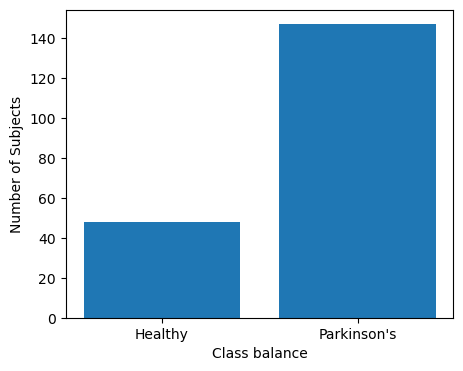

In [16]:
# Class Balance
labels = ["Healthy", "Parkinson's"]
counts = [np.sum(y_parkinson == 0), np.sum(y_parkinson == 1)]

plt.figure(figsize=(5, 4))
plt.bar(labels, counts)
plt.ylabel("Number of Subjects")
plt.xlabel("Class balance")
plt.show()

**Visualize Distribution of Features**

Visual inspection of feature distributions shows that HNR, RPDE, and DFA provides strong separation between classes, with healthy subjects exhibiting higher values. The combination with other features would also increase efficacy in classification.

In [17]:
parkinson_data["status"] = y_parkinson

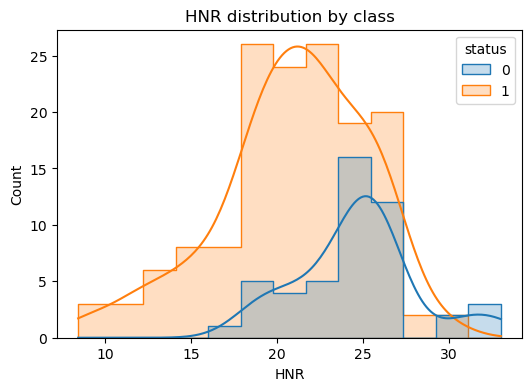

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="HNR", hue="status", kde=True, element="step")
plt.title("HNR distribution by class")
plt.show()

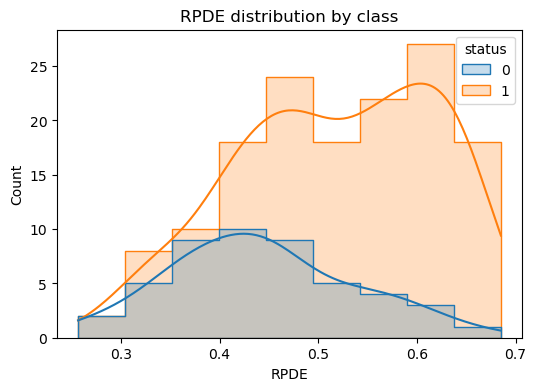

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="RPDE", hue="status", kde=True, element="step")
plt.title("RPDE distribution by class")
plt.show()

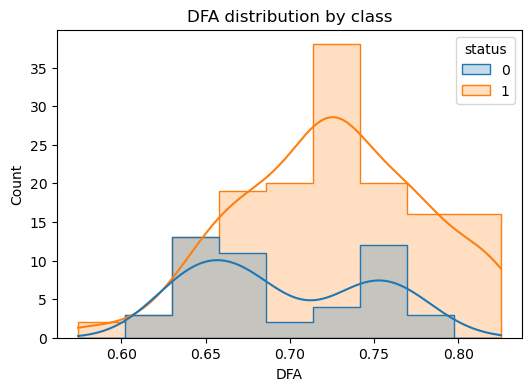

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="DFA", hue="status", kde=True, element="step")
plt.title("DFA distribution by class")
plt.show()

## Baseline and Candidate Models

**Baseline model: Logistic Regression**

Logistic Regression is the baseline model because this is a binary classification task. The target variable is `status`, where 0 represents healthy subjects and 1 represents Parkinson's disease.

An important hyperparameter is `C`, which controls regularization strength. Smaller values of `C` apply stronger regularization.

Any more complex model must exceed a validation F1-score of 0.893 to be considered useful (which is our current result). Improvements must be measured on the validation set to ensure generalization and avoid overfitting.


**Candidate model 1: Random Forest Classifier**

_Why this model:_

Random Forest is suitable because it can capture non-linear relationships between the voice features and Parkinson's disease status. This is useful because biomedical voice measurements may interact in complex ways.

Feature scaling is not required because tree-based models split features using thresholds. The scale of the feature does not affect how the tree makes splits.

- _Expected advantage:_ It does not require feature scaling and can model non-linear patterns. It also provides feature importance.

- _Expected risk:_ Random Forest can overfit, especially because the dataset is small. If the trees are too deep, the model may memorize the training data instead of generalizing well.


- An important hyperparameter is `max_depth`, which controls how deep each tree can grow. Deeper trees can fit the training data more closely but may overfit.



**Candidate model 2: Support Vector Machine**

_Why this model:_

Support Vector Machine is useful for small biomedical datasets because it tries to find a strong decision boundary between classes. Using an RBF (Radial Basis Function) kernel allows the model to capture non-linear separation between healthy and Parkinson's samples.

Feature scaling is required because SVM is distance-based. If features are on different scales, the model may give too much importance to features with larger values.


- _Expected advantage:_ It can perform well on small datasets and can create non-linear decision boundaries.

- _Expected risk:_ It requires feature scaling and is less interpretable than Logistic Regression. Its performance also depends strongly on hyperparameters such as `C` and `gamma`.

- An important hyperparameter is `C`, which controls the trade-off between a wider margin and classification errors. Another important hyperparameter for the RBF kernel is `gamma`.


**Candidate model 3: K-Nearest Neighbors**

_Why this model:_

KNN is a simple distance-based model that classifies a sample based on the labels of its nearest neighbors. It is useful as an additional comparison model.

Feature scaling is required because KNN uses distances between samples. Without scaling, features with larger numeric ranges would dominate the distance calculation.


- _Expected advantage:_ It is simple and intuitive. It can work well if similar voice profiles belong to the same class.

- _Expected risk:_ It requires feature scaling and may perform poorly when there are many features or noisy measurements. It can also be sensitive to the value of `n_neighbors`.

- An important hyperparameter is `n_neighbors`, which controls how many nearby samples are used to classify a new sample.


**Ranking Models: Most Interpretable to Least Interpretable**

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest
4. Support Vector Machine with RBF kernel

Logistic Regression is the most interpretable because each feature has a coefficient. KNN is simple to understand but does not produce a clear formula. Random Forest can provide feature importance, but the full model is harder to interpret. SVM with RBF kernel is the least interpretable because the decision boundary is complex.

**Model Most Likely to Overfit**

Random Forest is expected to overfit most easily if the trees are allowed to become too deep. This is because each tree can learn very specific patterns from the training data, especially in a small dataset. SVM with an RBF kernel can also overfit if `C` or `gamma` are not well controlled. Logistic Regression is less likely to overfit because it is simpler, but it may underfit if the real relationship between the voice features and Parkinson's disease is non-linear.


### Train, Validation, and Test Strategy

We split the data using stratified random sampling: first into 80% train + validation and 20% test (maintaining class proportions), then split the train+validation into 75% training and 25% validation to ensure each set represents the original class distribution.

The dataset is split into **117 training samples, 39 validation samples, and 39 test samples**, with the 117 training samples used to fit the model, 39 validation samples to tune hyperparameters, and 39 test samples held out for final evaluation.

Each split maintains the original **the original class distribution (~75% Parkinson's, ~25% healthy)**: training set has 88 Parkinson's and 28 healthy cases, validation set has 29 Parkinson's and 10 healthy cases, and test set has 29 Parkinson's and 9 healthy cases, preserving class proportions across all splits.

The test set must remain untouched during model selection because using it to compare models would allow the model to implicitly learn from the test data, inflating performance estimates and resulting in overly optimistic metrics that won't generalize to truly new data in practice.


In [21]:
# Section 8 - Train, validation, and test split template

X_train_full, X_test, y_train_full, y_test = train_test_split(
     X_parkinson_clean,
     y_parkinson,
     test_size=0.20,
     random_state=42,
     stratify=y_parkinson
 )

X_train, X_val, y_train, y_val = train_test_split(
     X_train_full,
     y_train_full,
     test_size=0.25,  
     random_state=42,
     stratify=y_train_full
 )

# Shape for test, validation, and training sets
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_test_full shape: {X_test.shape}")
print(f"Training class counts: {np.unique(y_train, return_counts=True)}")
print(f"Test class counts: {np.unique(y_test, return_counts=True)}")

X_train_full shape: (156, 20)
X_test_full shape: (39, 20)
Training class counts: (array([0, 1]), array([28, 89]))
Test class counts: (array([0, 1]), array([10, 29]))


**Feature Scaling**

In [22]:
# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

train_pred = model.predict(X_train_scaled)
val_pred = model.predict(X_val_scaled)

### Comparing Models: Logistic Regression vs. Random Forest

**Primary metric:**

F1-Score is the primary metric because it balances precision and recall, providing a single score that accounts for class imbalance and prevents the model from simply predicting the majority class to achieve high accuracy.

**Secondary metrics:**

Recall (sensitivity), Precision, and Confusion Matrix are secondary metrics because they detail how many sick patients are correctly identified (recall), how many predicted positives are actually sick (precision), and the breakdown of all prediction types.

***Why these metrics are appropriate:***

These metrics are appropriate because the dataset is imbalanced (75% Parkinson's, 25% healthy), making accuracy misleading, and for medical diagnosis, both false alarms (precision) and missed cases (recall) matter, but recall is prioritized since missing a disease case is clinically more critical than a false alarm.

**Which error is more biologically problematic, false positives or false negatives?**

False negatives directly harm patient outcomes by delaying or preventing treatment, whereas false positives only result in unnecessary follow-up testing; in medical diagnosis, the cost of missing a disease is always higher than the cost of additional testing, especially for a progressive neurological condition like 
Parkinson's disease.


#### Final Comparison

Both models were trained on the same stratified split. Logistic Regression was fitted on scaled features with class_weight='balanced'/ Random Forest used raw features with max_depth=10 and min_samples_leaf=5 to limit overfitting.

The two models perform comparably on the validation set (F1: 0.893 vs 0.897), but differ in their error profiles. Random Forest produces one fewer false negative (3 vs 4), meaning it catches more Parkinson's cases, while Logistic Regression is more conservative with fewer false positives (2 vs 3). 

Random Forest also achieves a higher ROC-AUC (0.934 vs 0.886), indicating stronger overall discrimination across thresholds. The visible gap between Random Forest's train and validation F1 (0.972 vs 0.897) confirms mild overfitting, though validation performance remains competitive.

Despite Random Forest's edge in recall and ROC-AUC, Logistic Regression is selected as the final model for its interpretability: its coefficients directly quantify the direction and magnitude of each feature's contribution to the Parkinson's prediction, which is meaningful in a clinical context.

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_lr = model.predict(X_val_scaled)
train_pred_lr = model.predict(X_train_scaled)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=5,
    random_state=42, class_weight="balanced"
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
train_pred_rf = rf.predict(X_train)

# Confusion matrix values
cm_lr = confusion_matrix(y_val, y_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

cm_rf = confusion_matrix(y_val, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

# Single results table
results_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "train_f1": f1_score(y_train, train_pred_lr),
        "val_f1": f1_score(y_val, y_pred_lr),
        "val_recall": recall_score(y_val, y_pred_lr),
        "val_precision": precision_score(y_val, y_pred_lr),
        "val_accuracy": accuracy_score(y_val, y_pred_lr),
        "val_roc_auc": roc_auc_score(y_val, model.predict_proba(X_val_scaled)[:, 1]),
        "TN": tn_lr, "FP": fp_lr, "FN": fn_lr, "TP": tp_lr,
        "notes": "Scaled, class_weight=balanced"
    },
    {
        "model": "Random Forest",
        "train_f1": f1_score(y_train, train_pred_rf),
        "val_f1": f1_score(y_val, y_pred_rf),
        "val_recall": recall_score(y_val, y_pred_rf),
        "val_precision": precision_score(y_val, y_pred_rf),
        "val_accuracy": accuracy_score(y_val, y_pred_rf),
        "val_roc_auc": roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1]),
        "TN": tn_rf, "FP": fp_rf, "FN": fn_rf, "TP": tp_rf,
        "notes": "No scaling, depth=10, min_samples_leaf=5"
    }
])

results_df

,model,train_f1,val_f1,val_recall,val_precision,val_accuracy,val_roc_auc,TN,FP,FN,TP,notes
0,Logistic Regression,0.886228,0.892857,0.862069,0.925926,0.846154,0.886207,8,2,4,25,"Scaled, class_weight=balanced"
1,Random Forest,0.972067,0.896552,0.896552,0.896552,0.846154,0.934483,7,3,3,26,"No scaling, depth=10, min_samples_leaf=5"


## Diagnostic Plots and Learning Curves

The learning curve shows training and CV validation F1 as training size increases. The final train F1 is 0.8865 and validation F1 is 0.8529, with a gap of 0.034, indicating no severe overfitting or underfitting. The confusion matrix confirms 8 TN, 25 TP, 2 FP, 4 FN on the validation set. A next step would be tuning regularization strength C, since the model is stable and slightly stronger regularization might close the remaining gap. Validation performance is the relevant signal for model selection because it reflects generalization to unseen data, unlike training performance which only measures memorization.

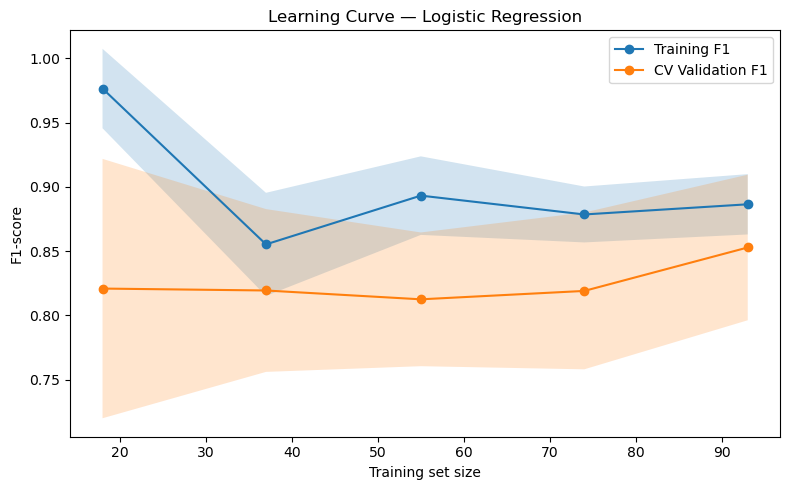

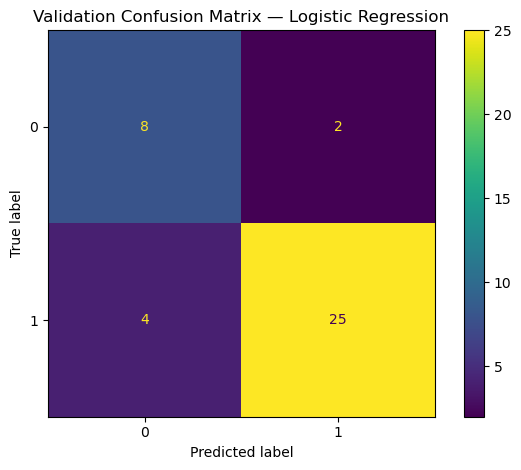

Train F1: 0.8865 | CV Val F1: 0.8529 | Gap: 0.0336
Diagnosis: no severe bias or variance


In [29]:
# Diagnostic Plots
# Model already selected in Section 10: Logistic Regression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ]),
    X=X_train, y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=cv, scoring="f1", n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean,   marker="o", label="CV Validation F1")
plt.fill_between(train_sizes, train_mean - train_scores.std(axis=1), train_mean + train_scores.std(axis=1), alpha=0.2)
plt.fill_between(train_sizes, val_mean   - val_scores.std(axis=1),   val_mean   + val_scores.std(axis=1),   alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("F1-score")
plt.title("Learning Curve — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix (already fitted model from Section 10)
ConfusionMatrixDisplay.from_estimator(model, X_val_scaled, y_val)
plt.title("Validation Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

# Bias-variance summary
gap = train_mean[-1] - val_mean[-1]
print(f"Train F1: {train_mean[-1]:.4f} | CV Val F1: {val_mean[-1]:.4f} | Gap: {gap:.4f}")
print("Diagnosis:", "high variance" if gap > 0.10 else "high bias" if val_mean[-1] < 0.75 else "no severe bias or variance")

## Final Reflections

### Chosen final model

The final selected model is Logistic Regression.

### Why this model

Logistic Regression was selected because it achieved the best validation F1-score in the current model comparison. It obtained a validation F1-score of 0.8929, which was higher than the Random Forest validation F1-score of 0.8772. The diagnostic learning curve also showed no severe high bias or high variance, with a small train-validation gap of 0.0336. This suggests that the model generalizes reasonably well.

### Why not the baseline only

In this project, Logistic Regression was used as the baseline model, but it was not selected only because it was the baseline. It was selected because it performed well on validation data, showed stable diagnostic behavior, and is interpretable. Therefore, the final choice is supported by performance and not only by simplicity.

### Why not the more complex alternative

Random Forest was not selected because it had a lower validation F1-score than Logistic Regression in the current comparison. Although Random Forest is more flexible and can capture non-linear patterns, it is also less interpretable and may have a higher risk of overfitting, especially with a small dataset. Since the performance advantage was not present on validation data, the simpler and more interpretable Logistic Regression model was preferred.

### Main evidence supporting this choice

The main evidence is the validation F1-score, where Logistic Regression achieved 0.8929 compared with 0.8772 for Random Forest. The learning curve also supported this choice because the training and validation F1-scores were reasonably close, suggesting no severe overfitting. The confusion matrix showed that Logistic Regression correctly classified most validation samples, with 8 true negatives, 25 true positives, 2 false positives, and 4 false negatives.

### Main limitation

The main limitation is that Logistic Regression is a linear model. It may not capture complex non-linear relationships between the voice features and Parkinson’s disease status. Also, the dataset is relatively small and imbalanced, so the model should be validated on more data before being trusted in a real clinical setting.





## Final Test Evaluation

The final model (Logistic Regression, C=1, class_weight='balanced') was refit on the combined train+validation set (156 samples) before evaluating once on the held-out test set.
Test F1 (0.823) is lower than validation F1 (0.893), which is expected, validation performance is always somewhat optimistic since model selection was based on it. The ROC-AUC remains strong at 0.928, suggesting the model discriminates well across thresholds even when the threshold-specific F1 drops. The main weakness is recall (0.724): 8 of 29 Parkinson's cases in the test set were missed, which matters clinically. This is partly attributable to the small and imbalanced dataset rather than a fundamental model failure — conclusions should not be generalized without validation on a larger independent cohort.

   Metric  Test performance
 F1-score          0.823529
   Recall          0.724138
Precision          0.954545
 Accuracy          0.769231
  ROC-AUC          0.927586

Classification report:
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.95      0.72      0.82        29

    accuracy                           0.77        39
   macro avg       0.74      0.81      0.75        39
weighted avg       0.85      0.77      0.78        39



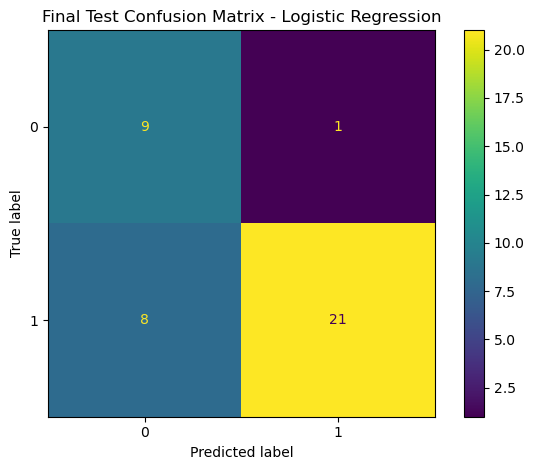

In [30]:
# Combine training and validation data after final model selection
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Final selected model: Logistic Regression
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Fit final model on training + validation data
final_model.fit(X_train_full, y_train_full)

# Evaluate once on the test set
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Test metrics
test_f1 = f1_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

test_results = pd.DataFrame({
    "Metric": ["F1-score", "Recall", "Precision", "Accuracy", "ROC-AUC"],
    "Test performance": [test_f1, test_recall, test_precision, test_accuracy, test_roc_auc]
})

print(test_results.to_string(index=False))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("Final Test Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

## Biological interpretation


The strongest model signals are spread1, MDVP:APQ, PPE, D2, MDVP:Jitter, spread2, MDVP:Shimmer, MDVP:PPQ, Shimmer:APQ5, and MDVP:RAP. These were identified from the largest absolute Logistic Regression coefficients.

These signals are biologically plausible because Parkinson’s disease can affect speech motor control, and many of these features measure voice instability, perturbation, or nonlinear vocal patterns.

The model does not prove causality. It does not show that these voice features cause Parkinson’s disease; it only shows that they are useful for prediction in this dataset.

A useful follow-up would be external validation on a larger independent dataset to check whether the same features remain important and whether the model generalizes to new subjects.

In [31]:
# Biological interpretation

# Get the Logistic Regression model from the final pipeline
log_reg = final_model.named_steps["logistic_regression"]

# Get feature names
feature_names = X_train.columns

# Get coefficients
coefficients = log_reg.coef_[0]

# Create coefficient table
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute coefficient": np.abs(coefficients)
})

# Sort by strongest signals
coef_df = coef_df.sort_values(by="Absolute coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Absolute coefficient
16,spread1,1.211487,1.211487
10,MDVP:APQ,1.110250,1.110250
19,PPE,0.739081,0.739081
18,D2,0.586283,0.586283
3,MDVP:Jitter,-0.553600,0.553600
17,spread2,0.472582,0.472582
7,MDVP:Shimmer,0.440291,0.440291
5,MDVP:PPQ,-0.417476,0.417476
9,Shimmer:APQ5,0.352669,0.352669
4,MDVP:RAP,0.349620,0.349620


## Limitations

The main limitation is the **small dataset size**. The dataset contains only 195 samples, so the model may not generalize well to a larger or more diverse population.

Another limitation is **class imbalance**. There are more Parkinson’s cases than healthy controls, which can affect model learning and evaluation. Although class weighting and F1-score were used to reduce this problem, imbalance can be a concern.

The model also missed 8 Parkinson’s cases on the final test set. These **false negatives** are important in a medical context because they represent diseased subjects predicted as healthy.

Finally, the features are voice measurements, not direct biological measurements. Therefore, the model can suggest useful predictive patterns, but it cannot prove a biological mechanism or causality.

A larger independent dataset would be needed to confirm the model performance and validate whether the same voice features remain important.